In [1]:
import pandas as pd 
import numpy as np
data = r'D:\Country-development-analysis\global-development-analysis\data\Country-data.csv'
df = pd.read_csv(data)
df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [2]:
"""Shared chart styling + a country-labelling helper used by every plot below.

Run this once, right after loading the data. Every chart cell in this notebook
depends on the names defined here (TIER_COLORS, SEQ, DIV, style, label_points),
so if you get a NameError further down, re-run this cell."""

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm, PowerNorm

# --- design tokens -----------------------------------------------------------
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, ACCENT = "#e1e0d9", "#c3c2b7", "#e34948"
TIER_COLORS = ["#86b6ef", "#2a78d6", "#0d366b"]          # ordinal: low -> high income

# sequential (one hue, light -> dark) for magnitude such as child mortality
SEQ = LinearSegmentedColormap.from_list("seq_blue", [
    "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
# diverging (two opposite hues + neutral midpoint) for signed values such as r
DIV = LinearSegmentedColormap.from_list("div_br", [
    "#0d366b", "#256abf", "#6da7ec", "#cde2fb", "#f0efec",
    "#f6c9c9", "#e88a89", "#d03b3b", "#8f1f1f"])

mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "figure.dpi": 110,
})


def style(ax, axis="both"):
    """Recessive hairline grid behind the marks."""
    ax.grid(True, axis=axis)
    ax.set_axisbelow(True)
    ax.tick_params(length=3, width=0.8, labelsize=9)


def label_points(ax, xs, ys, names, priority, fontsize=7.2, max_labels=None,
                 color=INK2):
    """Name as many points as fit without overlapping, highest priority first.

    Greedy placement in display space: each name is tried at 8 offsets around its
    own marker and kept only if it clears every marker and every label already
    placed. That is what lets these scatters name ~55 of the 167 countries
    instead of the usual handful, with no collisions to clean up by hand.

    priority : array-like -- larger = labelled first. Distance from the fitted
               line works well: the countries that defy the trend get named.
    """
    fig = ax.figure
    fig.canvas.draw()                      # a renderer is needed for text extents
    rend = fig.canvas.get_renderer()

    pts = ax.transData.transform(np.column_stack([xs, ys]))
    taken = [mpl.transforms.Bbox.from_bounds(px - 5, py - 5, 10, 10) for px, py in pts]

    offsets = [(7, 0, "left", "center"), (-7, 0, "right", "center"),
               (0, 6, "center", "bottom"), (0, -6, "center", "top"),
               (6, 5, "left", "bottom"), (-6, 5, "right", "bottom"),
               (6, -5, "left", "top"), (-6, -5, "right", "top")]

    placed = 0
    for i in np.argsort(-np.asarray(priority)):
        if max_labels is not None and placed >= max_labels:
            break
        for dx, dy, ha, va in offsets:
            t = ax.annotate(names[i], (xs[i], ys[i]), textcoords="offset points",
                            xytext=(dx, dy), ha=ha, va=va, fontsize=fontsize,
                            color=color, zorder=5)
            bb = t.get_window_extent(renderer=rend).expanded(1.05, 1.15)
            inside = (bb.x0 >= ax.bbox.x0 and bb.x1 <= ax.bbox.x1
                      and bb.y0 >= ax.bbox.y0 and bb.y1 <= ax.bbox.y1)
            if inside and not any(bb.overlaps(o) for o in taken):
                taken.append(bb)
                placed += 1
                break
            t.remove()                     # collided or off-axes: try next offset
    return placed

## Data_understanding


This stage focuses on gaining a clear understanding of the dataset before performing any analysis. It involves examining the structure, contents, and quality of the data to identify patterns, anomalies, and potential issues. Understanding the data helps ensure that the analysis is based on reliable and meaningful information.

Key activities in this stage include:
- Reviewing the dataset schema and variable names
- Checking data types and missing values
- Identifying outliers and inconsistencies
- Understanding relationships between variables
- Exploring the distribution of important features

A strong data understanding phase is essential because it lays the foundation for accurate analysis, interpretation, and decision-making. It helps researchers and analysts determine whether the data is suitable for the intended objectives and what preprocessing steps may be required.

In [3]:
df.shape # 167 row 10 columns

(167, 10)

In [4]:
"""Describe the information about the dataset which includes the number
of non-null entries,
data types, 
and memory usage."""


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [5]:
""" describe the numerical columns in the dataset """

df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [6]:
df['country'].unique()


array(['Afghanistan', 'Albania', 'Algeria', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia',
       'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan',
       'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'Brunei', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia',
       'Cameroon', 'Canada', 'Cape Verde', 'Central African Republic',
       'Chad', 'Chile', 'China', 'Colombia', 'Comoros',
       'Congo, Dem. Rep.', 'Congo, Rep.', 'Costa Rica', "Cote d'Ivoire",
       'Croatia', 'Cyprus', 'Czech Republic', 'Denmark',
       'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador',
       'Equatorial Guinea', 'Eritrea', 'Estonia', 'Fiji', 'Finland',
       'France', 'Gabon', 'Gambia', 'Georgia', 'Germany', 'Ghana',
       'Greece', 'Grenada', 'Guatemala', 'Guinea', 'Guinea-Bissau',
       'Guyana', 'Haiti', 'Hungary', 'Iceland', 'India', 'Indonesia',
       'Iran

In [7]:
len(df['country'].unique())

167

In [8]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

## Exploitory Data Analysis


If we bucket countries into income tiers (low/mid/high, via quartiles on income), how do average child_mort, life_expec, and health spending compare across tiers? — establishes that income tier is a meaningful proxy for wellbeing.

In [10]:
df.head(5)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


,countries,avg_child_mort,avg_life_expec,avg_health
income_tier,,,,
Low (bottom 25%),42,88.06,59.76,6.81
Middle (25-75%),83,28.12,71.77,6.11
High (top 25%),42,8.54,78.95,8.23


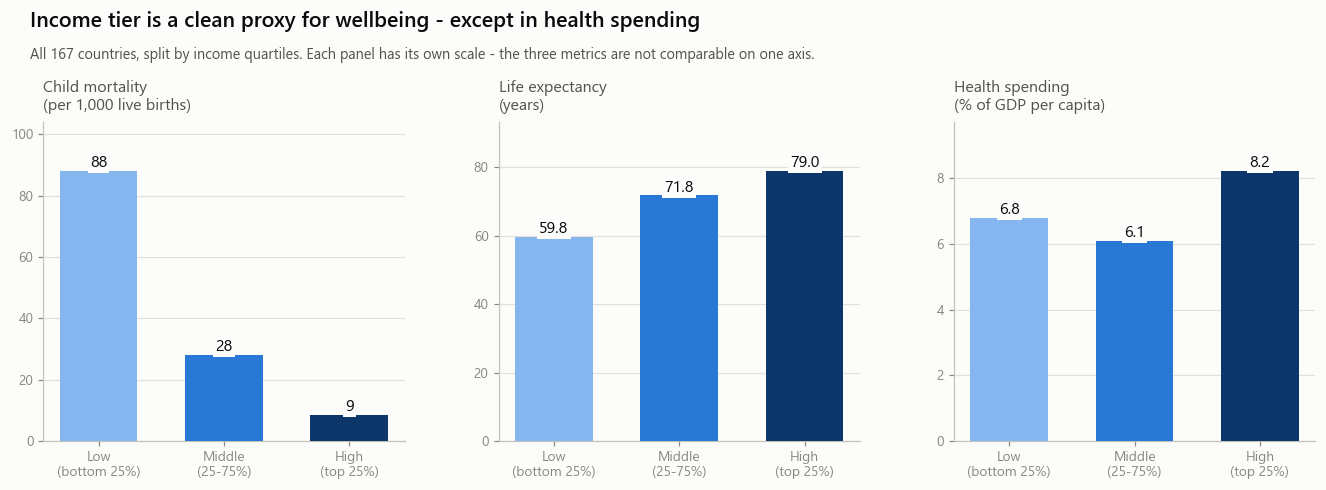

In [11]:
"""Q1 -- bucket all 167 countries into income tiers via quartiles, then compare
the three metrics. One panel per metric: child_mort (2.6-208), life_expec
(32-82) and health (1.8-17.9) share no common scale, so putting them on one
y-axis would flatten health spending into a meaningless line."""

df["income_tier"] = pd.qcut(
    df["income"], q=[0, .25, .75, 1.0],
    labels=["Low (bottom 25%)", "Middle (25-75%)", "High (top 25%)"])

tier_summary = df.groupby("income_tier", observed=True).agg(
    countries=("country", "size"),
    avg_child_mort=("child_mort", "mean"),
    avg_life_expec=("life_expec", "mean"),
    avg_health=("health", "mean"),
).round(2)
display(tier_summary)

metrics = [("avg_child_mort", "Child mortality\n(per 1,000 live births)", "{:.0f}"),
           ("avg_life_expec", "Life expectancy\n(years)", "{:.1f}"),
           ("avg_health", "Health spending\n(% of GDP per capita)", "{:.1f}")]

fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.6))
for ax, (col, label, fmt) in zip(axes, metrics):
    vals = tier_summary[col].values
    bars = ax.bar(range(3), vals, color=TIER_COLORS, width=0.62, zorder=3)
    for b, v in zip(bars, vals):                       # direct-label every bar: only 3
        ax.text(b.get_x() + b.get_width() / 2, v, fmt.format(v), ha="center",
                va="bottom", fontsize=10.5, color=INK, zorder=4,
                bbox=dict(facecolor=SURFACE, edgecolor="none", pad=1.5))
    ax.set_xticks(range(3), [t.replace(" (", "\n(") for t in tier_summary.index],
                  fontsize=9)
    ax.set_title(label, loc="left", fontsize=10.5, color=INK2, pad=8)
    ax.set_ylim(0, vals.max() * 1.18)
    style(ax, axis="y")

fig.suptitle("Income tier is a clean proxy for wellbeing - except in health spending",
             x=0.045, ha="left", fontsize=14, color=INK, weight="semibold")
fig.text(0.045, 0.885,
         "All 167 countries, split by income quartiles. Each panel has its own scale - "
         "the three metrics are not comparable on one axis.",
         ha="left", fontsize=9.5, color=INK2)
fig.subplots_adjust(top=0.76, bottom=0.13, left=0.055, right=0.98, wspace=0.26)
plt.show()

In [ ]:
"""Which 15 countries have the highest
child_mort combined with the lowest gdpp? — 
narrows the "at risk" shortlist using a groupby/sort rather than just eyeballing."""
countries_with_high_child_mort_low_gdp = df.groupby('country').agg(
    {'child_mort': 'mean'
     , 'gdpp': 'mean'}).sort_values(by=['child_mort', 'gdpp'], ascending=[False, True]).head(15)
countries_with_high_child_mort_low_gdp

,child_mort,gdpp
country,,
Haiti,208.0,662.0
Sierra Leone,160.0,399.0
Chad,150.0,897.0
Central African Republic,149.0,446.0
Mali,137.0,708.0
Nigeria,130.0,2330.0
Niger,123.0,348.0
Angola,119.0,3530.0
"Congo, Dem. Rep.",116.0,334.0


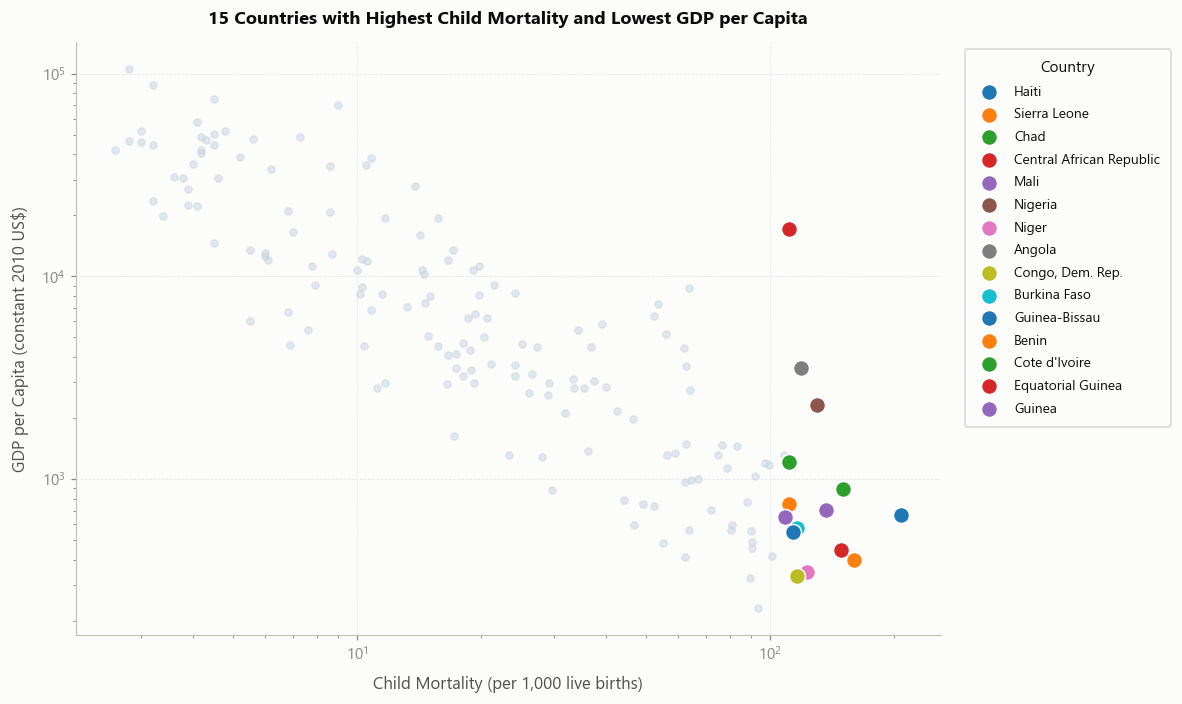

In [26]:
import matplotlib.patheffects as pe

top15 = top15.sort_values('child_mort', ascending=False).reset_index(drop=True)
colors = plt.cm.tab10(np.arange(len(top15)) % 10)

fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(df['child_mort'], df['gdpp'], s=22, color='#c8d3e0',
           alpha=0.5, zorder=2)

for (_, r), c in zip(top15.iterrows(), colors):
    ax.scatter(r['child_mort'], r['gdpp'], s=110, color=c,
               edgecolor='white', linewidth=1.0, zorder=4,
               label=r['country'])

ax.set_xscale('log')
ax.set_yscale('log')

ax.legend(title='Country', loc='upper left', bbox_to_anchor=(1.02, 1.0),
          fontsize=9, title_fontsize=10, frameon=True, borderpad=0.8,
          labelspacing=0.7)

ax.grid(True, which='major', linestyle='--', linewidth=0.5,
        color='#d8dee6', alpha=0.7, zorder=1)
ax.set_axisbelow(True)

ax.set_xlabel('Child Mortality (per 1,000 live births)', fontsize=11, color=INK2, labelpad=8)
ax.set_ylabel('GDP per Capita (constant 2010 US$)', fontsize=11, color=INK2, labelpad=8)
ax.set_title('15 Countries with Highest Child Mortality and Lowest GDP per Capita',
             fontsize=12, fontweight='bold', color=INK, pad=12)

plt.subplots_adjust(right=0.78)
plt.show()

Conclusion. The fifteen highest child-mortality countries are concentrated in Sub-Saharan Africa (Haiti excepted) and occupy the low-GDP, high-mortality tail of the distribution. The inverse relationship is strong and approximately log-linear, but cross-sectional data cannot establish causal direction — both variables likely reflect common structural determinants.